In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sign-language-mnist


In [3]:
# Load the CSV files (make sure they're uploaded to your Kaggle environment first)
train_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test.csv')

In [4]:
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
train_df.head()

Training data shape: (27455, 785)
Testing data shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


<ipython-input-5-2856570bd87f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


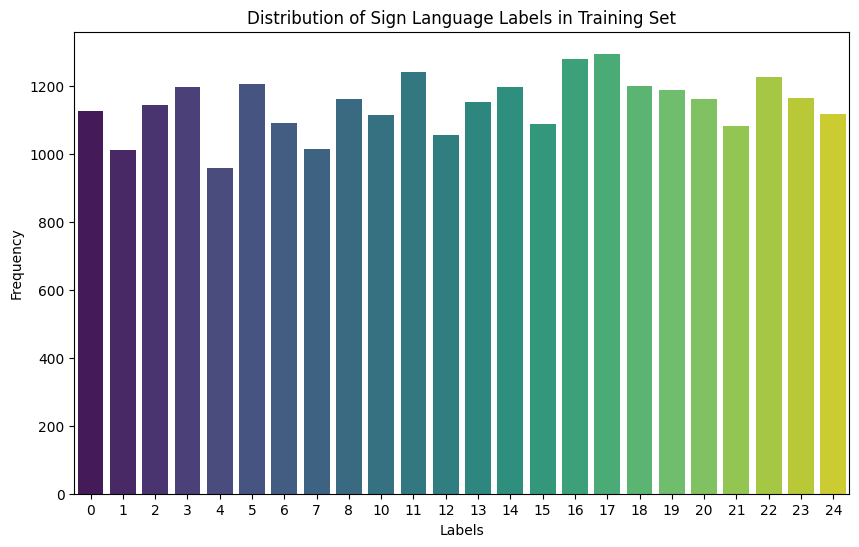

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title('Distribution of Sign Language Labels in Training Set')
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.show()

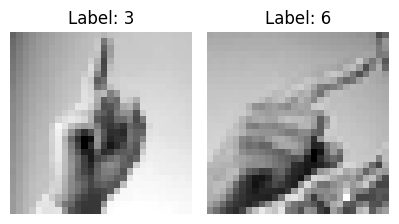

In [6]:
# Function to display images with labels
def show_images(data, labels, num=2):
    plt.figure(figsize=(10, 5))
    for i in range(num):
        plt.subplot(2, 5, i+1)
        image = data.iloc[i, 1:].values.reshape(28, 28)  # Skip label column
        plt.imshow(image, cmap='grey')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show the first 10 training images
show_images(train_df, train_df['label'].values)


In [7]:
# Separate features and labels
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Reshape X_train and X_test for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to one-hot encoded
y_train = to_categorical(y_train, num_classes=25)
y_test = to_categorical(y_test, num_classes=25)



In [8]:
model = Sequential()

# 1st Convolutional layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolutional layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the output
model.add(Flatten())

# Fully connected Dense layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Prevent overfitting

# Output layer - 25 classes
model.add(Dense(25, activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [70]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test, y_test))

Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.1933 - loss: 2.6968 - val_accuracy: 0.7235 - val_loss: 0.8809
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.6584 - loss: 0.9978 - val_accuracy: 0.8256 - val_loss: 0.5050
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.7887 - loss: 0.5926 - val_accuracy: 0.8798 - val_loss: 0.3734
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8498 - loss: 0.4181 - val_accuracy: 0.8918 - val_loss: 0.3293
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8821 - loss: 0.3266 - val_accuracy: 0.9077 - val_loss: 0.2643
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9101 - loss: 0.2445 - val_accuracy: 0.9151 - val_loss: 0.2304
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9249 - loss: 0.2086 - val_accuracy: 0.9112 - val_loss: 0.2615
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.9340 - loss: 0.1843 - 

In [9]:
# Predict test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(y_true_labels, y_pred_labels, output_dict=True)

# Convert report to DataFrame for better formatting
report_df = pd.DataFrame(report).transpose()

# Display the formatted report
display(report_df)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,331.000000
1,0.043358,0.469907,0.079390,432.000000
2,0.000000,0.000000,0.000000,310.000000
3,0.000000,0.000000,0.000000,245.000000
4,0.089392,0.150602,0.112191,498.000000
5,0.000000,0.000000,0.000000,247.000000
6,0.000000,0.000000,0.000000,348.000000
7,0.000000,0.000000,0.000000,436.000000
8,0.000000,0.000000,0.000000,288.000000
10,0.000000,0.000000,0.000000,331.000000


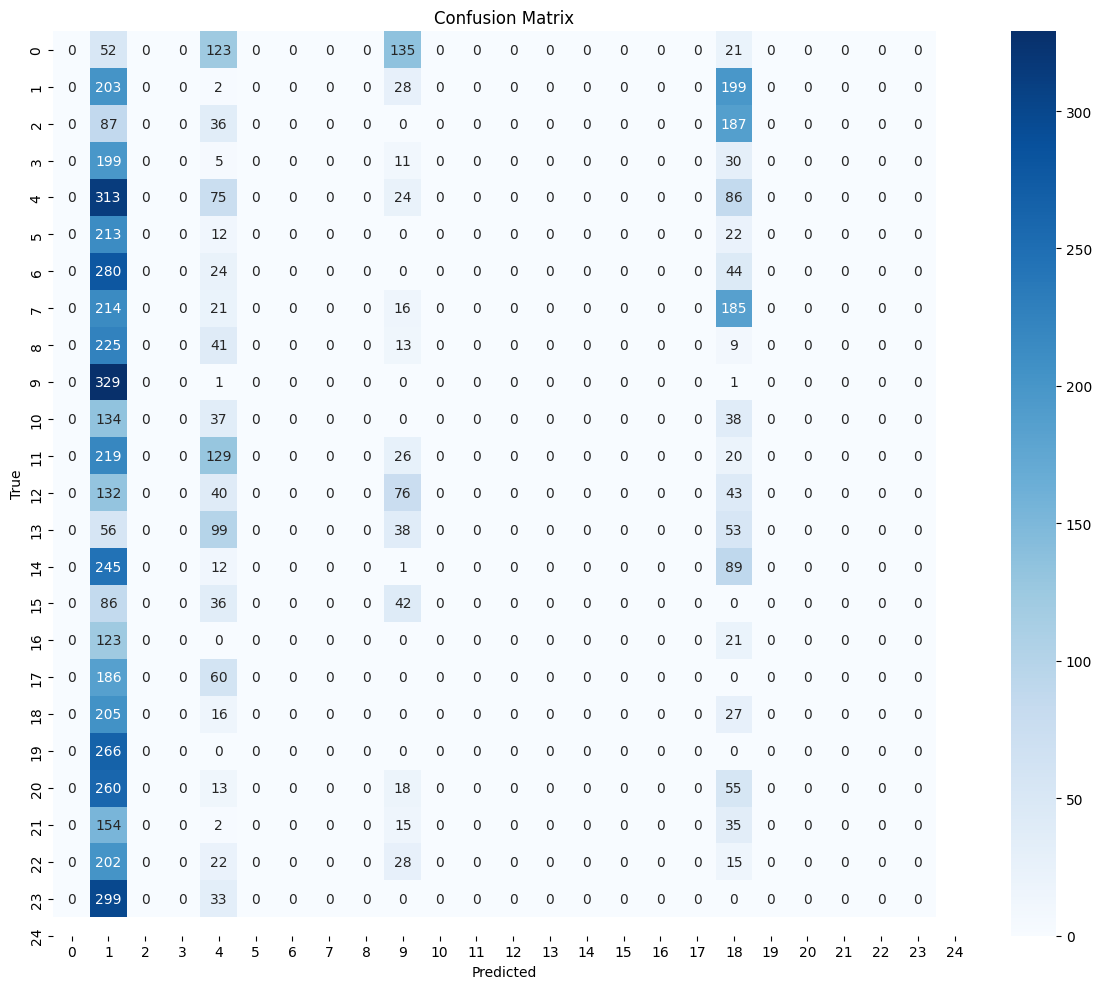

In [10]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix # Import confusion_matrix

# Plot confusion matrix with adjustments
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=range(25),  # Assuming 25 classes (0-24)
            yticklabels=range(25))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()  # Adjusts subplot parameters for a tight layout
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


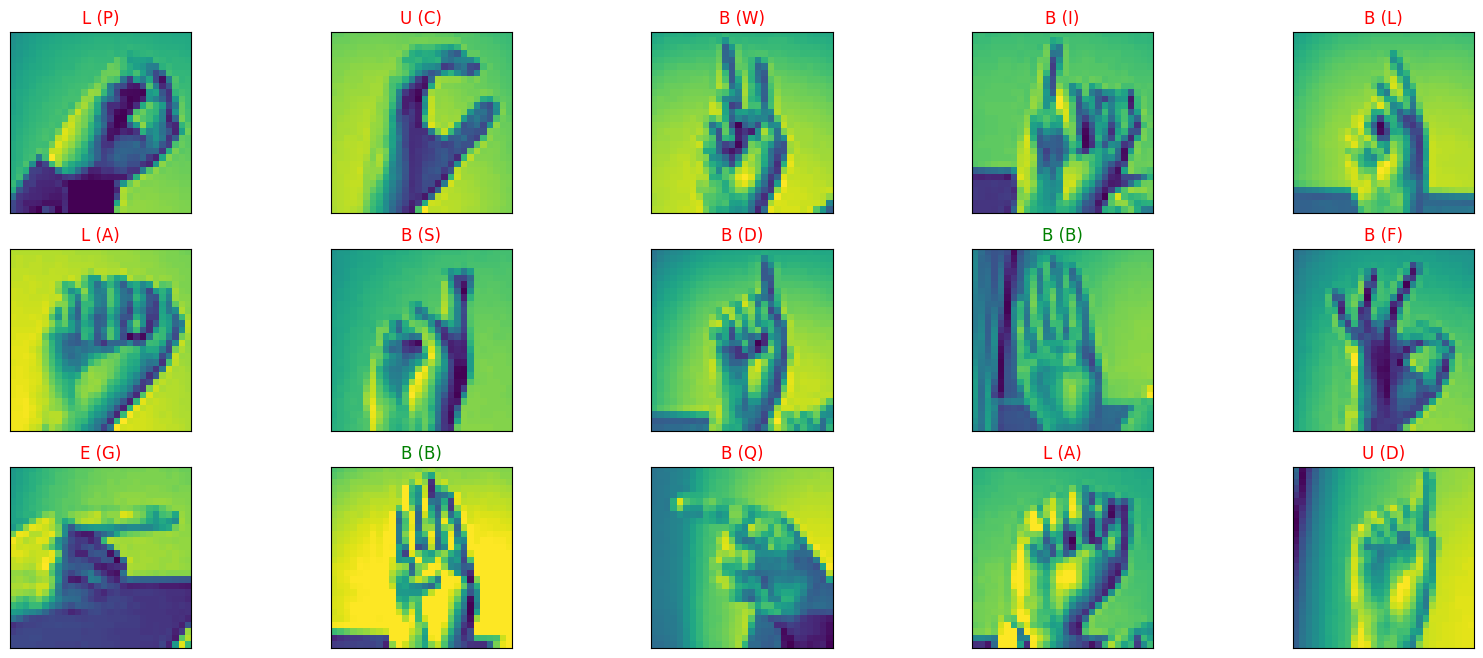

In [11]:
sign_language_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'] # Include 'Z' or 'J', which represents the 25th class

y_hat = model.predict(X_test)

# Plot a random sample of 10 test images, their predicted labels and ground truth
figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(X_test[index]))
    predict_index = np.argmax(y_hat[index])
    true_index = np.argmax(y_test[index])

    # Add title for each image, handling potential index errors
    ax.set_title("{} ({})".format(sign_language_labels[predict_index], sign_language_labels[true_index]),
                 color=("green" if predict_index == true_index else "red"))

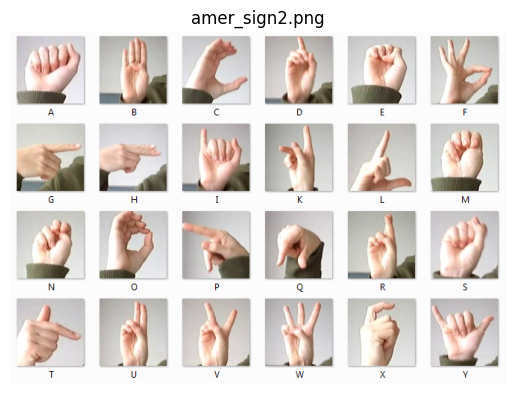

In [12]:
#  Try loading with mpimg (supports common formats like png, jpg, etc.)
image = mpimg.imread('/kaggle/input/sign-language-mnist/amer_sign2.png') # Correct the file path and extension to '.png'
plt.imshow(image)
plt.title('amer_sign2.png')
plt.axis('off') # Optional: Turn off axis labels and ticks
plt.show()




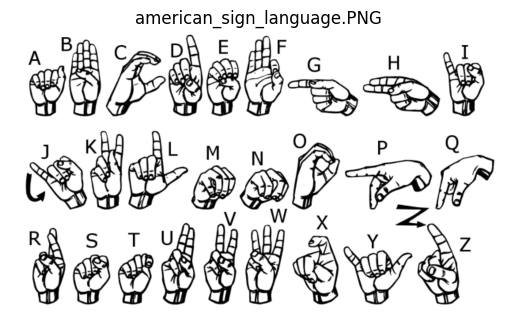

In [13]:
#  Try loading with mpimg (supports common formats like png, jpg, etc.)
image = mpimg.imread('/kaggle/input/sign-language-mnist/american_sign_language.PNG') # Correct the file path and extension to '.png'
plt.imshow(image)
plt.title('american_sign_language.PNG')
plt.axis('off') # Optional: Turn off axis labels and ticks
plt.show()


###***COMPARISON***

In [14]:
# Assuming you have 25 classes (A–Y except J & Z for static gestures)
y_train_cat = to_categorical(y_train, num_classes=25)
y_test_cat = to_categorical(y_test, num_classes=25)

# Reshape image data to 3 channels (from 1) to match pre-trained model input requirements
X_train_3ch = np.repeat(X_train, 3, axis=-1)
X_test_3ch = np.repeat(X_test, 3, axis=-1)


##**AlexNet**

In [15]:
def create_alexnet():
    model = Sequential([
        Conv2D(96, kernel_size=(3,3), strides=(1,1), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(pool_size=(2,2)),
        Conv2D(256, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Conv2D(384, kernel_size=(3,3), activation='relu'),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(25, activation='softmax')
    ])
    return model

##**VGG**

In [16]:
def create_vgg():
    base_model = VGG16(include_top=False, input_shape=(32,32,3), weights=None)
    x = base_model.output
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(25, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

In [50]:
def compile_and_train_model(model, X, y, name):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X, y, epochs=3, batch_size=64, validation_split=0.1, verbose=1)
    test_loss, test_acc = model.evaluate(X_test_3ch if X.shape[-1] == 3 else X_test, y_test)
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    return test_acc

In [51]:
# Instantiate and train each model, storing the accuracies
alexnet_model = create_alexnet()
acc_alexnet = compile_and_train_model(alexnet_model, X_train, y_train, "AlexNet")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 168s 428ms/step - accuracy: 0.2943 - loss: 2.3244 - val_accuracy: 0.9232 - val_loss: 0.2465
Epoch 2/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 198s 419ms/step - accuracy: 0.9144 - loss: 0.2526 - val_accuracy: 0.9909 - val_loss: 0.0351
Epoch 3/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 201s 418ms/step - accuracy: 0.9792 - loss: 0.0681 - val_accuracy: 1.0000 - val_loss: 0.0034
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9193 - loss: 0.2862
AlexNet Test Accuracy: 0.9184


In [52]:
# Assuming your labels are integers in range 0 to 24 for 25 classes
# Check if y_train and y_test are already one-hot encoded
if y_train.ndim == 2 and y_train.shape[1] == 25:  # Already one-hot encoded
    y_train_cat = y_train  # No need to apply to_categorical
else:
    y_train_cat = to_categorical(y_train, num_classes=25)

if y_test.ndim == 2 and y_test.shape[1] == 25:  # Already one-hot encoded
    y_test_cat = y_test  # No need to apply to_categorical
else:
    y_test_cat = to_categorical(y_test, num_classes=25)

In [53]:
# Instantiate and train VGG model
vgg_model = create_vgg()
acc_vgg = compile_and_train_model(vgg_model, X_train_3ch, y_train_cat, "VGG")

Epoch 1/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 2607s 7s/step - accuracy: 0.0394 - loss: 3.2037 - val_accuracy: 0.0477 - val_loss: 3.1817
Epoch 2/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 2784s 7s/step - accuracy: 0.0441 - loss: 3.1851 - val_accuracy: 0.0477 - val_loss: 3.1822
Epoch 3/3
387/387 ━━━━━━━━━━━━━━━━━━━━ 2629s 7s/step - accuracy: 0.0456 - loss: 3.1814 - val_accuracy: 0.0477 - val_loss: 3.1798
225/225 ━━━━━━━━━━━━━━━━━━━━ 77s 341ms/step - accuracy: 0.0203 - loss: 3.2065
VGG Test Accuracy: 0.0201


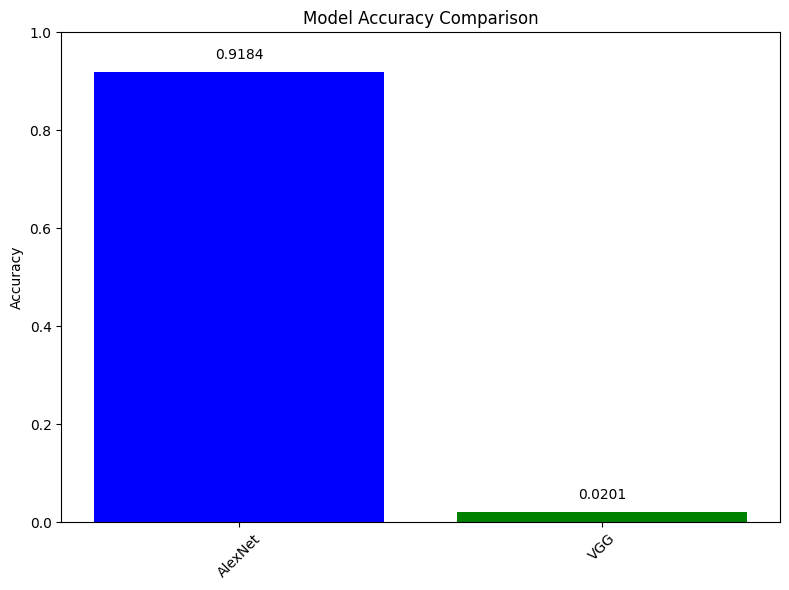

In [72]:
import matplotlib.pyplot as plt

# Assuming you have acc_alexnet and acc_vgg values stored from training

def plot_comparison(acc_alexnet, acc_vgg):
    # Create a bar chart to compare accuracies
    models = ['AlexNet', 'VGG']
    accuracies = [acc_alexnet, acc_vgg]

    plt.figure(figsize=(8, 6))
    plt.bar(models, accuracies, color=['blue', 'green'])
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])  # Set y-axis limits to 0-1 for accuracy
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

    # Add accuracy values as text above the bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()



# Call the function to create the plot
plot_comparison(acc_alexnet, acc_vgg)



***CONCLUSION***

*AlexNet significantly outperforms VGG on the Sign Language MNIST dataset, achieving ~92% accuracy compared to VGG's ~2%. This difference suggests AlexNet is better suited for this task, possibly due to its simpler architecture. Therefore, AlexNet is the preferred model for this application.*